In [1]:
import os
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/dataset')
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/')
from dataset.dataset_utils import *
from model.ES_net_mixer import *
from model import LightingModel
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json

In [2]:
train_dataset, val_dataset= get_dataset(
        data_dir="/home/linhang/workbench/Earthquake_data/",
        window_size=140,
        forecast_horizon=14,
        lape_dim=30,
        geo_percentage=0.3,
        sem_percentage=0.3,
        time_resolution=14,
        earthquake_catalog_window=1400
        )

In [3]:
def find_activate_area(earthquake_history,earthquake_future,energy_predict,topk):
    energy_catalog_sum = earthquake_future.sum(axis = 1).cpu().numpy()
    topk_index = np.argsort(energy_catalog_sum)[-topk:]
    earthquake_history_topk = earthquake_history[:,topk_index,:].squeeze(-1).cpu().numpy()
    earthquake_future_topk = earthquake_future[topk_index].permute(1,0).cpu().numpy()
    energy_predict_topk = energy_predict[topk_index].permute(1,0).cpu().numpy()
    return earthquake_history_topk,earthquake_future_topk,energy_predict_topk,topk_index

In [4]:
model = LightingModel.load_from_checkpoint("/home/linhang/workbench/workbench/Earthquake_predictor/Result/ES_net_mixer_longterm_california/checkpoints/last.ckpt")
model.eval()

LightingModel(
  (model): ES_net_mixer(
    (earthquake_embedding): DataEmbedding(
      (value_embedding): TokenEmbedding(
        (token_embed): Linear(in_features=1, out_features=128, bias=True)
        (norm): Identity()
      )
      (position_encoding): PositionalEmbedding()
      (spatial_embedding): LaplacianPE(
        (embedding_lap_pos_enc): Linear(in_features=30, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (location_embedding): LocationEmbedding(
        (location_embed): Linear(in_features=2, out_features=128, bias=True)
        (norm): Identity()
      )
    )
    (gnss_embedding_trend): DataEmbedding(
      (value_embedding): TokenEmbedding(
        (token_embed): Linear(in_features=4, out_features=128, bias=True)
        (norm): Identity()
      )
      (position_encoding): PositionalEmbedding()
      (spatial_embedding): LaplacianPE(
        (embedding_lap_pos_enc): Linear(in_features=30, out_features=128, bias=True)
      

In [27]:

train_loader = DataLoader(
    train_dataset, batch_size=2, shuffle=True, collate_fn=train_dataset.collate_fn,num_workers=127
)
val_loader = DataLoader(
    val_dataset, batch_size=2, shuffle=False, collate_fn=val_dataset.collate_fn,num_workers=127
)


In [37]:
sample_batch = next(iter(train_loader))
sample_batch

with torch.no_grad():
    predictions = model.predict_step(sample_batch, 0)


In [38]:
earthquake_history_topk,earthquake_future_topk,energy_predict,topk_index = find_activate_area(sample_batch['log_energy_history'][0],predictions['log_energy_future'][0],predictions['energy_predict'][0],8)

In [39]:
earthquake_location_topk = np.round(denormalize_locations(predictions['earthquake_location'][0][topk_index]).detach().cpu().numpy(),2)

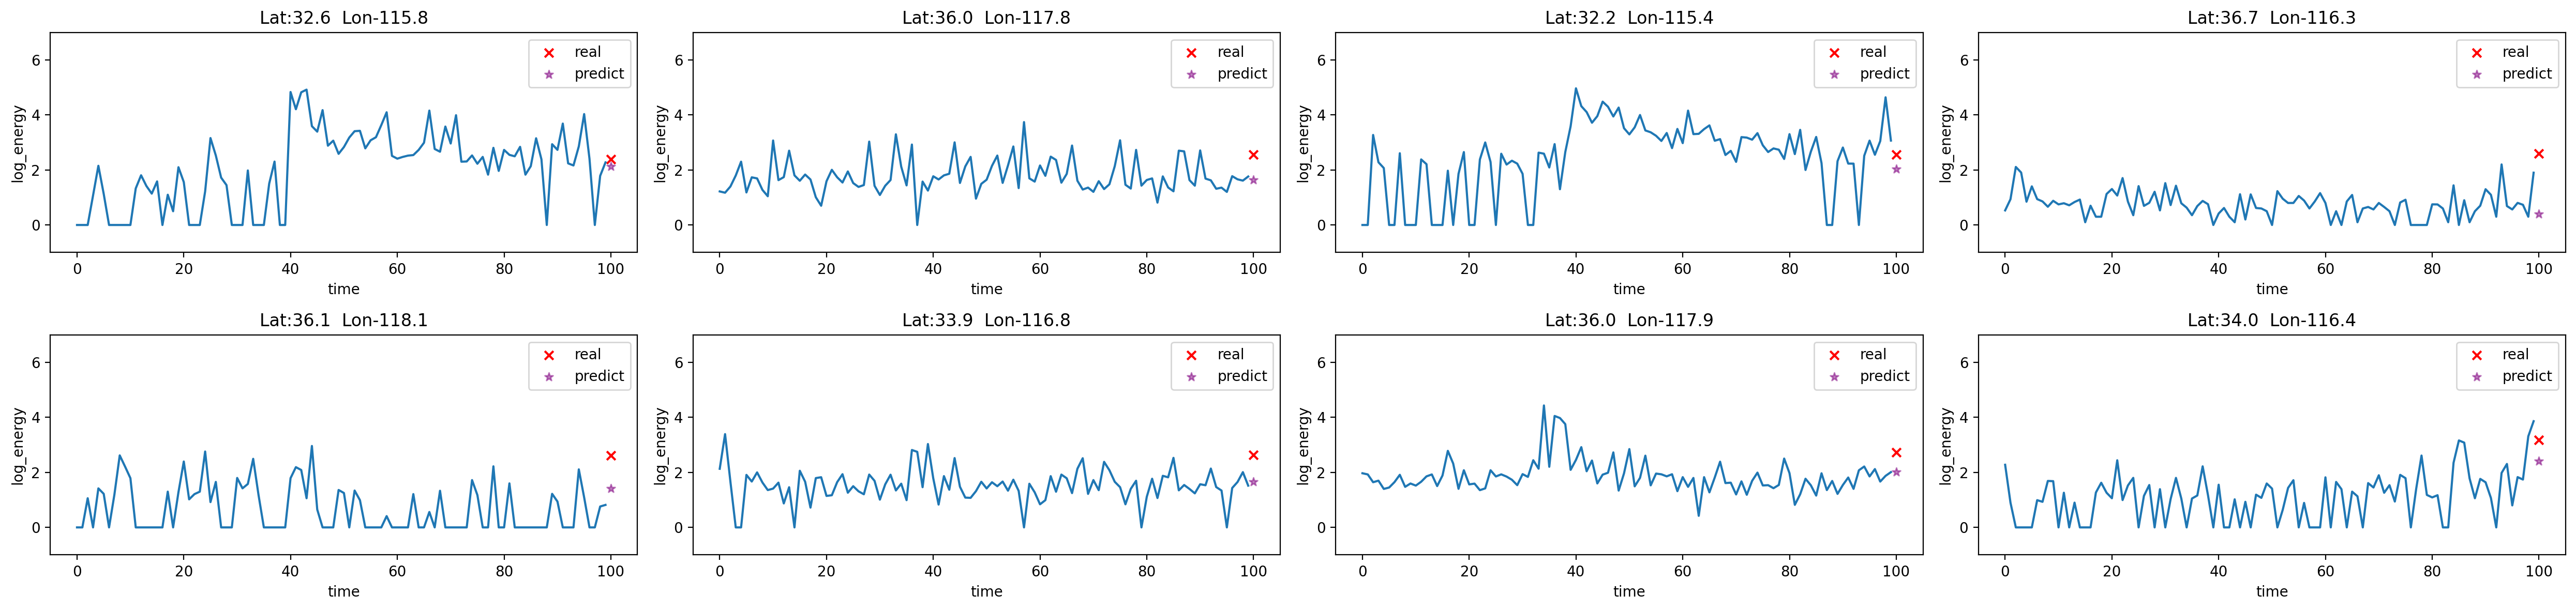

In [40]:
plt.figure(figsize=(25,6),dpi=200)
for i in range(8):
    plt.subplot(2,4,i+1)

    plt.plot(range(len(earthquake_history_topk[:,i])),earthquake_history_topk[:,i])
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(earthquake_future_topk[:,i])),earthquake_future_topk[:,i],c='r',marker='x',label='real')
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(energy_predict[:,i])),energy_predict[:,i],c='purple',marker='*',label='predict',alpha=0.5)
    plt.title('Lat:'+str(earthquake_location_topk[i][0])+'  Lon'+str(earthquake_location_topk[i][1]))
    plt.legend()
    plt.xlabel('time')
    plt.ylabel('log_energy')
    plt.ylim(-1,7)
plt.tight_layout()
plt.show()

In [10]:
energy_predict_all = []
earthquake_future_all = []
energy_history_all = []
earthquake_happen_all = []
with torch.no_grad():
    for batch in train_loader:
        predictions = model.predict_step(batch, 0)
        energy_predict_all.append(predictions['energy_predict'])
        earthquake_future_all.append(predictions['log_energy_future'])
        energy_history_all.append(batch['log_energy_history'])
        earthquake_happen_all.append(batch['earthquake_happen'])
energy_predict_all = torch.cat(energy_predict_all)
earthquake_future_all = torch.cat(earthquake_future_all)
energy_history_all = torch.cat(energy_history_all)
earthquake_happen_all = torch.cat(earthquake_happen_all)


In [11]:
def calculate_earthquake_threshold(energy_predict_all,earthquake_future_all,threshold):
    earthquake_happen_predict = (energy_predict_all>threshold)
    earthquake_happen_real = (earthquake_future_all>threshold)
    return earthquake_happen_predict,earthquake_happen_real

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(energy_predict_all, earthquake_happen_all, threshold = 3):
    """
    计算并绘制混淆矩阵，同时打印各类评估指标。
    
    Args:
        energy_predict_all: 预测的能量值 (torch.Tensor)
        earthquake_happen_all: 地震发生的真实标签 (torch.Tensor)
    Returns:
        energy_predict: numpy 数组，预测的能量值
        earthquake_target: numpy 数组，地震发生的真实标签
    """
    labels = [0, 1]
    energy_predict = energy_predict_all.cpu().numpy().flatten()
    earthquake_target = earthquake_happen_all.cpu().numpy().flatten()

    # 将连续的预测值转为分类标签
    earthquake_happen_predict, earthquake_happen_real = calculate_earthquake_threshold(energy_predict, earthquake_target, threshold=3)

    # 计算混淆矩阵
    confusion_matrix_result = confusion_matrix(earthquake_happen_real, earthquake_happen_predict, labels=labels)

    # 提取混淆矩阵中的元素
    TP = confusion_matrix_result[1, 1]
    TN = confusion_matrix_result[0, 0]
    FP = confusion_matrix_result[0, 1]
    FN = confusion_matrix_result[1, 0]

    # 计算各类指标
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate
    TNR = TN / (FP + TN) if (FP + TN) > 0 else 0  # True Negative Rate
    Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    Accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    Error = (FP + FN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    Aggregative_Score = (TPR + Precision + Accuracy) / 3

    # 绘制混淆矩阵
    sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predict')
    plt.ylabel('Real')
    plt.title('Confusion Matrix')

    # 打印指标
    print(f"TPR (Recall): {TPR:.2f}")
    print(f"TNR (Specificity): {TNR:.2f}")
    print(f"Precision: {Precision:.2f}")
    print(f"Accuracy: {Accuracy:.2f}")
    print(f"Error: {Error:.2f}")
    print(f"FPR: {FPR:.2f}")
    print(f"Aggregative Score: {Aggregative_Score:.2f}")

    # 显示混淆矩阵
    plt.show()
    
    return energy_predict, earthquake_target

TPR (Recall): 0.25
TNR (Specificity): 1.00
Precision: 0.72
Accuracy: 0.99
Error: 0.01
FPR: 0.00
Aggregative Score: 0.65


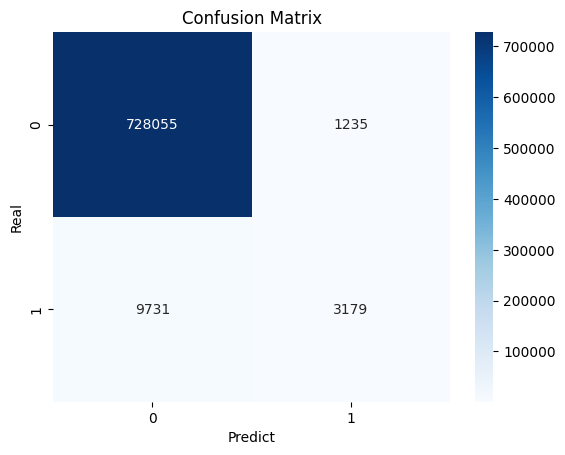

In [13]:
energy_predict,earthquake_target = plot_confusion_matrix(energy_predict_all,earthquake_future_all)

In [20]:
def plot_error(energy_predict,earthquake_target,error): 
    plt.figure(figsize=(10, 10))
    plt.scatter(earthquake_target,energy_predict, alpha=0.6, label="Data points")

    # 绘制基准线 y = x
    x = np.linspace(0, 7, 100)
    plt.plot(x, x, color="purple", linestyle="-", label="y=x")

    # 绘制 10% 误差线
    plt.plot(x, (1+error) * x, color="gray", linestyle="--", label=f"{error*100}% error bounds")
    plt.plot(x, (1-error) * x, color="gray", linestyle="--")

    # 填充误差范围
    plt.fill_between(x, (1-error) * x, (1+error) * x, color="gray", alpha=0.2)

    # 图表设置
    plt.xlabel("Real Log Energy", fontsize=14)
    plt.ylabel("Predicted Log Energy", fontsize=14)
    plt.title(f"Scatter Error", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.xlim(-0.2, 7)
    plt.ylim(-0.2, 7)

    # 显示图表
    plt.show()

def plot_delta_error(energy_predict,earthquake_target,error): 
    plt.figure(figsize=(10, 10))
    plt.scatter(earthquake_target,energy_predict, alpha=0.6, label="Data points")

    # 绘制基准线 y = x
    x = np.linspace(min(earthquake_target.min(),energy_predict.min()), max(earthquake_target.max(),energy_predict.max()), 100)
    plt.plot(x, x, color="purple", linestyle="-", label="y=x")

    # 绘制 10% 误差线
    plt.plot(x, (1+error) * x, color="gray", linestyle="--", label=f"{error*100}% error bounds")
    plt.plot(x, (1-error) * x, color="gray", linestyle="--")

    # 填充误差范围
    plt.fill_between(x, (1-error) * x, (1+error) * x, color="gray", alpha=0.2)

    # 图表设置
    plt.xlabel("Real delta_Log Energy", fontsize=14)
    plt.ylabel("Predicted delta_Log Energy", fontsize=14)
    plt.title(f"Scatter Delta Error", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)

    # 显示图表
    plt.show()

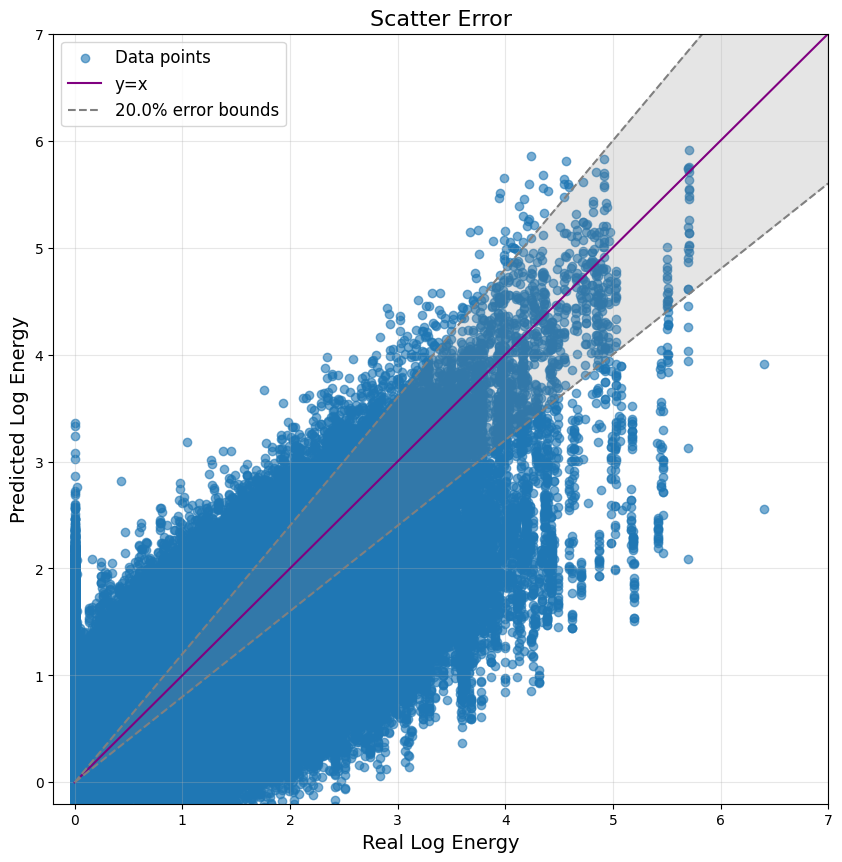

In [21]:
plot_error(energy_predict,earthquake_target,0.2)

In [22]:
energy_history_last = energy_history_all[:,-1,:,:].flatten().detach().cpu().numpy()

In [23]:
delta_energy_predict = energy_predict - energy_history_last
delta_energy_target = earthquake_target - energy_history_last

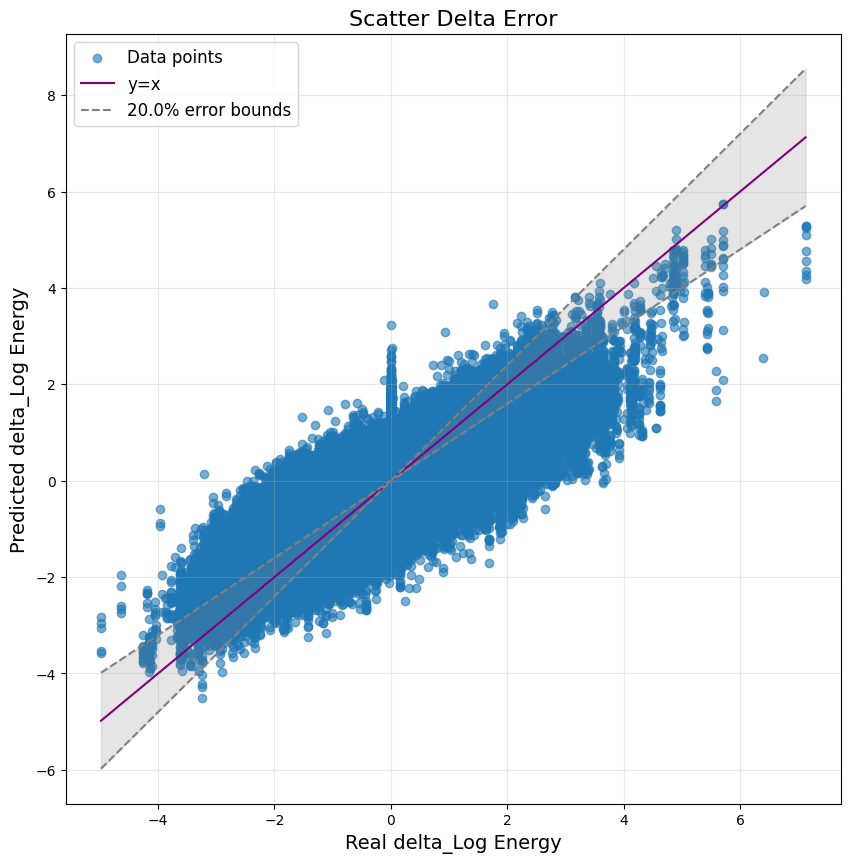

In [24]:
plot_delta_error(delta_energy_predict,delta_energy_target,0.2)

In [25]:
mse =np.power((energy_predict - earthquake_target),2).mean()
rmse = np.sqrt(mse)
print('rmse:', rmse)
print('mse:', mse)

rmse: 0.6026804
mse: 0.36322364
